In [1]:
# Prep system
# define hoppings: site1, site2 return -t*exp

In [2]:
import kwant
from matplotlib import pyplot as plt
from scipy.constants import physical_constants
import numpy as np
from math import atan2, pi, sqrt
import ipywidgets as widgets

In [3]:
m_el = physical_constants['electron mass'][0]
m_eff = 0.067
eV = physical_constants['electron volt'][0]
hbar = physical_constants['Planck constant over 2 pi'][0]
el_charge = physical_constants['elementary charge'][0]
hh = physical_constants['Planck constant'][0]

In [4]:
a = 0.5 * 10**(-9)
t = hbar**2 / (2 * m_el * m_eff * a**2) / eV

In [5]:
def onsite(site):
    return 4 * t

In [6]:
# Only the hoppings now that there is a magnetic field
def hopping(site_0, site_1, B):
    x0, y0 = site_0.pos
    x1, y1 = site_1.pos
    C = 2 * np.pi * B * el_charge * 10**(-18) / hh
    return -t * np.exp(-0.5j * C * (y0 + y1) * (x0 - x1))

In [7]:
Rmax = 30
Rmin = 20
Wmin = -5
Wmax = 5

In [8]:
def shape(pos):
    x,y = pos
    return Rmin**2 < x**2 + y**2 < Rmax**2

In [9]:
def shape_lead(pos):
    x,y = pos
    return Wmin < y < Wmax

In [10]:
sys = kwant.Builder()
lat = kwant.lattice.square(a * 10**9, norbs = 1)

In [11]:
sys[lat.shape(shape, (0, Rmin + 1))] = onsite

In [12]:
sys[lat.neighbors()] = hopping

In [17]:
leadl = kwant.Builder(kwant.TranslationalSymmetry((-a * 10**9, 0)))
leadl[lat.shape(shape_lead, (0, 0))] = onsite
leadl[lat.neighbors()] = hopping
# Instead of writing right lead "leadr" we can reflect the 'leadl'
leadr = leadl.reversed()
sys.attach_lead(leadl)
sys.attach_lead(leadr)

[]

In [18]:
sysf = sys.finalized()

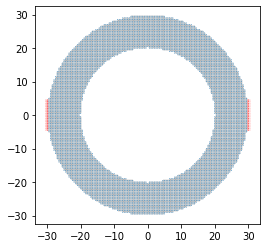

In [19]:
kwant.plot(sysf)

In [ ]:
# Task
# Copy code from upel and instead of U use B, u will obtain coductacne
# set E_f to 0.06 and Btab istead of Utab to [0,7]